# 06 — Machine Learning

**Input:** bảng `public.city_temperature_features` và file `data/processed/feature_metadata.json`, cả hai được bàn giao từ `05_feature_engineering.ipynb`.

**Output chính:** `models/model.pkl` (mô hình tốt nhất), `models/scaler.pkl` (nếu mô hình được chọn cần chuẩn hóa dữ liệu) và `models/model_metadata.json` (ghi lại feature, chỉ số đánh giá, thời điểm huấn luyện). Ba file này là thứ Notebook 07 và `app/` sẽ nạp lại để dự đoán.

**Bài toán:** dự báo `city_average_temperature` — nhiệt độ trung bình của một thành phố ở **tháng kế tiếp** — dùng đúng 19 đặc trưng mà Notebook 05 đã chọn, theo đúng thứ tự đã lưu trong `feature_metadata.json`.

> **Khác biệt có chủ đích so với `AGENTS_climate_project.md`:** mục 5.6 của tài liệu đó gợi ý huấn luyện tối thiểu 5 mô hình. Theo yêu cầu cụ thể cho notebook này, chỉ 3 mô hình được huấn luyện đầy đủ: **Linear Regression, Random Forest, XGBoost**. Đây là quyết định phạm vi được xác nhận, không phải thiếu sót.

## I. Giới thiệu

### 1.1. Mục tiêu của Notebook

Notebook này trả lời câu hỏi: **với 19 đặc trưng mà Notebook 05 đã xây dựng và chứng minh không rò rỉ dữ liệu, mô hình nào dự báo nhiệt độ thành phố tháng kế tiếp tốt nhất?**

Các việc chính:

1. Đọc đúng bảng đặc trưng và đúng hợp đồng (`feature_metadata.json`) mà Notebook 05 để lại.
2. Xử lý các dòng còn thiếu giá trị ở nhóm đặc trưng lịch sử.
3. Huấn luyện ba mô hình có bản chất khác nhau: một mô hình tuyến tính (Linear Regression) và hai mô hình dạng cây (Random Forest, XGBoost).
4. So sánh ba mô hình bằng số liệu đo trên tập **validation** — đúng tập mà Notebook 05 đã dành riêng cho việc chọn mô hình.
5. Chọn một mô hình, đánh giá **đúng một lần duy nhất** trên tập **test** để có con số báo cáo cuối cùng, rồi lưu lại cho Notebook 07.

### 1.2. Vai trò của Machine Learning trong dự án

Notebook 04 (EDA) mô tả dữ liệu, Notebook 05 (Feature Engineering) biến mô tả đó thành các biến số mô hình học được. Notebook 06 là bước biến các biến số đó thành một **hàm dự báo cụ thể**: đưa vào đặc điểm một thành phố ở một thời điểm, trả về một con số nhiệt độ dự kiến cho tháng sau.

Đây cũng là notebook duy nhất trong pipeline phải trả lời câu hỏi **đánh đổi**: mô hình đơn giản (Linear Regression) dễ giải thích và triển khai nhưng có thể bỏ lỡ quan hệ phi tuyến; mô hình phức tạp hơn (Random Forest, XGBoost) thường chính xác hơn nhưng nặng hơn và khó diễn giải hơn. Mục VIII sẽ cân nhắc đánh đổi này bằng số liệu thật, không phỏng đoán.

### 1.3. Pipeline

```text
Notebook 05 — Feature Engineering
   ↓ public.city_temperature_features + feature_metadata.json
Notebook 06 — Machine Learning (notebook này)
   ↓ huấn luyện, so sánh, chọn mô hình trên validation
   ↓ đánh giá một lần trên test
   ↓ models/model.pkl + models/scaler.pkl (nếu cần) + models/model_metadata.json
Notebook 07 — Prediction Demo
```

## II. Đọc dữ liệu

### 2.1. Nạp các thư viện cần thiết

`pandas`/`numpy` để xử lý bảng dữ liệu; `matplotlib` để vẽ biểu đồ đánh giá; `scikit-learn` cung cấp Linear Regression, Random Forest, các chỉ số đánh giá và `StandardScaler`; `xgboost` cung cấp mô hình Gradient Boosting hiệu quả trên dữ liệu lớn; `joblib` để lưu mô hình; `SQLAlchemy`/`psycopg2` để đọc PostgreSQL; `python-dotenv` để nạp cấu hình `.env`.

In [ ]:
import json
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5.5)
plt.rcParams['font.size'] = 10

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Thư viện đã sẵn sàng.')

Thư viện đã sẵn sàng.


### 2.2. Xác định thư mục dự án và đầu ra

Notebook có thể được mở từ thư mục gốc hoặc từ `notebooks_v1/`/`notebooks_v2/`. Hàm dưới tìm project root dựa trên hai thư mục ổn định `data/` và `models/`.

In [ ]:
def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc chứa cả data/ và models/."""
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'models').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa data/ và models/.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
CANDIDATES_DIR = MODELS_DIR / 'candidates'
REPORT_IMAGES_DIR = PROJECT_ROOT / 'reports' / 'images'
for directory in (MODELS_DIR, CANDIDATES_DIR, REPORT_IMAGES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

METADATA_PATH = PROCESSED_DIR / 'feature_metadata.json'

print('Project root :', PROJECT_ROOT)
print('Models dir   :', MODELS_DIR)

Project root : C:\Users\COMPUTER\Desktop\du_an_2\Global-Surface-Temperature-Analysis
Models dir   : C:\Users\COMPUTER\Desktop\du_an_2\Global-Surface-Temperature-Analysis\models


### 2.3. Đọc hợp đồng dữ liệu từ Notebook 05

`feature_metadata.json` là hợp đồng giữa Notebook 05 và Notebook 06: nó cho biết chính xác **tên và thứ tự 19 đặc trưng** (`feature_names`), tên biến mục tiêu, tên bảng PostgreSQL, các mốc năm chia tập, và số dòng kỳ vọng ở mỗi tập. Notebook 06 đọc đúng danh sách này thay vì tự chọn lại đặc trưng — nếu tự chọn lại, các kiểm tra chống rò rỉ dữ liệu ở Notebook 05 sẽ mất tác dụng.

In [ ]:
if not METADATA_PATH.is_file():
    raise FileNotFoundError(
        f'Không tìm thấy {METADATA_PATH}. Notebook 06 bắt buộc phải chạy sau Notebook 05.'
    )

with open(METADATA_PATH, encoding='utf-8') as handle:
    FEATURE_METADATA = json.load(handle)

TARGET_COLUMN = FEATURE_METADATA['target']
FEATURE_NAMES = list(FEATURE_METADATA['feature_names'])
KEY_COLUMNS = list(FEATURE_METADATA['key_columns'])
FEATURE_TABLE = FEATURE_METADATA['postgres_table']
TRAIN_CUTOFF_YEAR = FEATURE_METADATA['train_cutoff_year']
VALIDATION_START_YEAR = FEATURE_METADATA['validation_start_year']
FEATURE_FIT_CUTOFF_YEAR = FEATURE_METADATA['feature_fit_cutoff_year']
EXPECTED_SPLIT_COUNTS = FEATURE_METADATA['split_counts']
EXPECTED_ROW_COUNT = FEATURE_METADATA['row_count']

print(f'Biến mục tiêu       : {TARGET_COLUMN}')
print(f'Số đặc trưng        : {len(FEATURE_NAMES)}')
print(f'Bảng nguồn          : {FEATURE_TABLE}')
print(f'Feature-fit / Train : <= {FEATURE_FIT_CUTOFF_YEAR}')
print(f'Validation          : {VALIDATION_START_YEAR}–{TRAIN_CUTOFF_YEAR}')
print(f'Test                : > {TRAIN_CUTOFF_YEAR}')
print()
print('19 đặc trưng theo đúng thứ tự đã chốt ở Notebook 05:')
for position, name in enumerate(FEATURE_NAMES, start=1):
    group = FEATURE_METADATA['feature_details'][name]['group']
    availability = FEATURE_METADATA['feature_details'][name]['availability']
    print(f'  {position:>2}. {name:<26} [{group}, availability={availability}]')

Biến mục tiêu       : city_average_temperature
Số đặc trưng        : 19
Bảng nguồn          : public.city_temperature_features
Feature-fit / Train : <= 1983
Validation          : 1984–1993
Test                : > 1993

19 đặc trưng theo đúng thứ tự đã chốt ở Notebook 05:
   1. month_sin                  [Thời gian, availability=static]
   2. month_cos                  [Thời gian, availability=static]
   3. climatic_month_sin         [Thời gian, availability=static]
   4. climatic_month_cos         [Thời gian, availability=static]
   5. years_since_start          [Thời gian, availability=static]
   6. latitude                   [Địa lý, availability=static]
   7. abs_latitude               [Địa lý, availability=static]
   8. hemisphere_north           [Địa lý, availability=static]
   9. longitude                  [Địa lý, availability=static]
  10. abslat_x_month_sin         [Tương tác, availability=static]
  11. abslat_x_month_cos         [Tương tác, availability=static]
  12. loc_mont

Cột `availability` cho biết điều kiện dùng lúc dự báo thật: `static` (biết trước từ vị trí/ngày), `fit_stat` (cần bảng thống kê `feature_statistics.csv.gz`), `history` (cần lịch sử tháng trước của đúng thành phố). Notebook 07 phải tôn trọng đúng ba điều kiện này khi dựng input cho một dự báo mới.

### 2.4. Kết nối PostgreSQL bắt buộc

Notebook 06 chỉ đọc dữ liệu từ `public.city_temperature_features` — bảng chính thức mà Notebook 05 đã nạp và kiểm tra row count. Không có nhánh fallback CSV, để tránh vô tình huấn luyện trên một phiên bản dữ liệu khác với phiên bản đã qua kiểm tra rò rỉ.

In [ ]:
ENV_PATH = PROJECT_ROOT / '.env'
if not ENV_PATH.is_file():
    raise FileNotFoundError(f'Không tìm thấy {ENV_PATH}. Notebook 06 chỉ đọc dữ liệu từ PostgreSQL.')

import os

from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

load_dotenv(ENV_PATH, override=False)
required_env = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    raise ValueError(f'.env thiếu các biến: {missing_env}')

DB_ENGINE = create_engine(
    URL.create(
        drivername='postgresql+psycopg2',
        username=os.environ['DB_USER'],
        password=os.environ['DB_PASSWORD'],
        host=os.environ['DB_HOST'],
        port=int(os.environ['DB_PORT']),
        database=os.environ['DB_NAME'],
    ),
    pool_pre_ping=True,
    connect_args={'connect_timeout': 10},
)

table_name = FEATURE_TABLE.split('.')[-1]
with DB_ENGINE.connect() as connection:
    check = connection.execute(
        text(f"SELECT to_regclass('{FEATURE_TABLE}') IS NOT NULL AS table_exists")
    ).scalar()
if not check:
    raise RuntimeError(f'{FEATURE_TABLE} chưa tồn tại. Hãy chạy Notebook 05 trước.')
print(f'PASS: kết nối PostgreSQL thành công, {FEATURE_TABLE} tồn tại.')

PASS: kết nối PostgreSQL thành công, public.city_temperature_features tồn tại.


### 2.5. Đọc bảng đặc trưng

Chỉ đọc đúng các cột cần dùng: khóa nghiệp vụ, biến mục tiêu, 19 đặc trưng và hai cột nhãn `data_split`/`is_train_period`. `latitude`/`longitude` vừa là khóa nghiệp vụ vừa là đặc trưng nên chỉ được liệt kê một lần trong câu truy vấn.

In [ ]:
columns_to_read = list(KEY_COLUMNS)
for name in [TARGET_COLUMN] + FEATURE_NAMES + ['data_split', 'is_train_period']:
    if name not in columns_to_read:
        columns_to_read.append(name)

query = text(f"SELECT {', '.join(columns_to_read)} FROM {FEATURE_TABLE}")

start_time = time.time()
with DB_ENGINE.connect() as connection:
    df = pd.read_sql_query(query, connection)
print(f'Đã đọc {len(df):,} dòng x {df.shape[1]} cột trong {time.time() - start_time:,.1f} giây.')

Đã đọc 5,579,085 dòng x 27 cột trong 87.0 giây.


### 2.6. Kiểm tra kích thước dữ liệu

In [ ]:
if len(df) != EXPECTED_ROW_COUNT:
    raise RuntimeError(
        f'Số dòng đọc được ({len(df):,}) khác số dòng kỳ vọng trong metadata ({EXPECTED_ROW_COUNT:,}).'
    )
print(f'PASS: số dòng khớp metadata ({len(df):,} dòng, {df.shape[1]} cột).')

split_counts_actual = df['data_split'].value_counts().to_dict()
for split_name, expected_count in EXPECTED_SPLIT_COUNTS.items():
    actual_count = split_counts_actual.get(split_name, 0)
    status = 'PASS' if actual_count == expected_count else 'FAIL'
    print(f'{status}: {split_name:<10} kỳ vọng {expected_count:>9,} · thực tế {actual_count:>9,}')

PASS: số dòng khớp metadata (5,579,085 dòng, 27 cột).
PASS: train      kỳ vọng 4,468,327 · thực tế 4,468,327
PASS: test       kỳ vọng   736,478 · thực tế   736,478
PASS: validation kỳ vọng   374,280 · thực tế   374,280


### 2.7. Kiểm tra kiểu dữ liệu

`observation_date` được ép về kiểu ngày; `city_name`/`country_name`/`data_split` dùng `category` vì số giá trị duy nhất nhỏ; các cột số dùng `float32` để giảm bộ nhớ mà không mất thông tin (dữ liệu gốc chỉ có 3–4 chữ số thập phân).

In [ ]:
df['observation_date'] = pd.to_datetime(df['observation_date'])
for column in ('city_name', 'country_name', 'data_split'):
    df[column] = df[column].astype('category')
df['year'] = df['year'].astype('int16')
df['month'] = df['month'].astype('int8')
df['is_train_period'] = df['is_train_period'].astype('int8')
if df['hemisphere_north'].dtype != 'int8':
    df['hemisphere_north'] = df['hemisphere_north'].astype('bool').astype('int8')

numeric_columns = [TARGET_COLUMN] + [
    name for name in FEATURE_NAMES if name != 'hemisphere_north'
]
for column in numeric_columns:
    df[column] = df[column].astype('float32')

display(df.dtypes.to_frame('dtype'))
print(f'Bộ nhớ hiện tại: {df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')

,dtype
observation_date,datetime64[s]
city_name,category
country_name,category
latitude,float32
longitude,float32
year,int16
month,int8
city_average_temperature,float32
month_sin,float32
month_cos,float32


Bộ nhớ hiện tại: 494.9 MB


### 2.8. Xác định Feature và Target

In [ ]:
X_ALL_COLUMNS = FEATURE_NAMES
Y_COLUMN = TARGET_COLUMN

print(f'Target (y)  : {Y_COLUMN}')
print(f'Feature (X) : {len(X_ALL_COLUMNS)} cột — {X_ALL_COLUMNS}')
display(df[[Y_COLUMN] + X_ALL_COLUMNS].describe().T)

Target (y)  : city_average_temperature
Feature (X) : 19 cột — ['month_sin', 'month_cos', 'climatic_month_sin', 'climatic_month_cos', 'years_since_start', 'latitude', 'abs_latitude', 'hemisphere_north', 'longitude', 'abslat_x_month_sin', 'abslat_x_month_cos', 'loc_month_climatology', 'loc_temperature_std', 'temp_lag_1', 'temp_roll_mean_12', 'temp_anomaly_lag_12', 'land_temperature_lag_1', 'land_anomaly_lag_1', 'city_uncertainty_lag_1']


,count,mean,std,min,25%,50%,75%,max
city_average_temperature,"5,579,085.0000",17.5021,10.1935,-42.7040,11.6060,19.8260,25.6370,39.1560
month_sin,"5,579,085.0000",0.0013,0.7071,-1.0000,-0.5000,0.0000,0.8660,1.0000
month_cos,"5,579,085.0000",-0.0013,0.7071,-1.0000,-0.8660,0.0000,0.5000,1.0000
climatic_month_sin,"5,579,085.0000",0.0008,0.7071,-1.0000,-0.5000,0.0000,0.8660,1.0000
climatic_month_cos,"5,579,085.0000",-0.0008,0.7071,-1.0000,-0.8660,0.0000,0.5000,1.0000
years_since_start,"5,579,085.0000",75.5843,43.1309,0.0000,38.0000,76.0000,113.0000,150.0000
latitude,"5,579,085.0000",23.4698,23.1319,-52.2400,10.4500,28.1300,39.3800,69.9200
abs_latitude,"5,579,085.0000",29.4948,14.6960,0.8000,20.0900,29.7400,39.3800,69.9200
hemisphere_north,"5,579,085.0000",0.8311,0.3747,0.0000,1.0000,1.0000,1.0000,1.0000
longitude,"5,579,085.0000",34.9669,76.7631,-151.1300,-7.5400,43.6400,106.2200,159.5500


Bảng thống kê mô tả là bước kiểm tra hợp lý cuối cùng trước khi vào Mục III: `city_average_temperature` phải nằm trong khoảng nhiệt độ hợp lý (Notebook 03 đã ràng buộc bằng CHECK constraint), `month_sin`/`month_cos`/`climatic_month_sin`/`climatic_month_cos` phải nằm trong [-1, 1], và `hemisphere_north` chỉ nhận 0 hoặc 1.

## III. Chuẩn bị dữ liệu

### 3.1. Phát hiện các cột có vấn đề

19 đặc trưng đã được Notebook 05 chọn đều là số hoặc nhị phân — **không có cột dạng chữ cần encoding**. "Vấn đề" duy nhất còn lại là **giá trị thiếu (`NaN`)**: các đặc trưng có `availability = history` (trễ, trượt, bối cảnh toàn cầu) không thể tính cho những dòng đầu chuỗi của mỗi thành phố, và các đặc trưng `fit_stat` có thể thiếu nếu một vị trí chưa có đủ lịch sử ở giai đoạn feature-fit. Đây là điều Notebook 05 đã cảnh báo trước, không phải lỗi phát sinh ở đây.

In [ ]:
missing_report = (
    df[X_ALL_COLUMNS + [Y_COLUMN]]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame('Thiếu (%)')
)
missing_report = missing_report[missing_report['Thiếu (%)'] > 0]
if missing_report.empty:
    print('Không có cột nào thiếu giá trị.')
else:
    display(missing_report)

rows_with_any_missing = df[X_ALL_COLUMNS + [Y_COLUMN]].isna().any(axis=1)
print(
    f'Số dòng thiếu ít nhất một giá trị: {int(rows_with_any_missing.sum()):,} '
    f'({rows_with_any_missing.mean():.2%} tổng dữ liệu).'
)

,Thiếu (%)
temp_anomaly_lag_12,0.7668
temp_roll_mean_12,0.3712
temp_lag_1,0.0888
city_uncertainty_lag_1,0.0888
land_temperature_lag_1,0.0428
land_anomaly_lag_1,0.0428


Số dòng thiếu ít nhất một giá trị: 44,057 (0.79% tổng dữ liệu).


### 3.2. Xử lý các cột có vấn đề

Cách xử lý là **loại bỏ (drop) các dòng thiếu giá trị**, không điền (impute) giá trị thay thế. Lý do:

- Tỷ lệ thiếu nhỏ (thường dưới 2%), nên loại bỏ không làm mất nhiều thông tin.
- Điền giá trị thay thế cho đặc trưng trễ/climatology có nguy cơ tạo ra tín hiệu giả — chính là loại rủi ro mà Notebook 05 đã cố gắng loại bỏ.
- Cả ba mô hình trong notebook này (Linear Regression, Random Forest, XGBoost qua scikit-learn API) đều được so sánh trên **cùng một tập dữ liệu đã làm sạch**, để phần chênh lệch hiệu năng phản ánh đúng bản chất mô hình, không phải do mỗi mô hình thấy một tập dữ liệu khác nhau.

Việc loại bỏ được thực hiện **trong từng nhãn `data_split`**, để không làm lệch tỷ lệ giữa ba tập.

In [ ]:
rows_before = df.groupby('data_split', observed=True).size()

df_clean = df.dropna(subset=X_ALL_COLUMNS + [Y_COLUMN]).reset_index(drop=True)

rows_after = df_clean.groupby('data_split', observed=True).size()

comparison = pd.DataFrame({'Trước': rows_before, 'Sau': rows_after})
comparison['Đã loại'] = comparison['Trước'] - comparison['Sau']
comparison['Tỷ lệ loại (%)'] = (comparison['Đã loại'] / comparison['Trước'] * 100).round(2)
display(comparison)

print(f'Tổng số dòng: {len(df):,} → {len(df_clean):,} '
      f'(loại {len(df) - len(df_clean):,} dòng, {(1 - len(df_clean) / len(df)):.2%}).')

,Trước,Sau,Đã loại,Tỷ lệ loại (%)
data_split,,,,
test,736478,736478,0,0.0000
train,4468327,4424270,44057,0.9900
validation,374280,374280,0,0.0000


Tổng số dòng: 5,579,085 → 5,535,028 (loại 44,057 dòng, 0.79%).


### 3.3. Chia Train / Validation / Test

Notebook 06 **không chia lại ngẫu nhiên**. Đây là dữ liệu chuỗi thời gian: nếu chia ngẫu nhiên, một số dòng ở tập train có thể nằm ngay sau (về thời gian) các dòng ở tập test, khiến đặc trưng trễ của tập train "nhìn thấy" thông tin có được nhờ biết trước tương lai — một dạng rò rỉ dữ liệu tinh vi.

Notebook 05 đã chia sẵn theo thời gian và ghi vào cột `data_split`:

- **`train`** (≤ 1983): dùng để **huấn luyện** cả ba mô hình.
- **`validation`** (1984–1993): dùng để **so sánh và chọn** mô hình tốt nhất (Mục VII–VIII). Không dùng để huấn luyện.
- **`test`** (> 1993): giữ nguyên, chỉ mở ra **đúng một lần** ở Mục VIII để báo cáo số liệu cuối cùng.

In [ ]:
train_df = df_clean.loc[df_clean['data_split'] == 'train'].copy()
validation_df = df_clean.loc[df_clean['data_split'] == 'validation'].copy()
test_df = df_clean.loc[df_clean['data_split'] == 'test'].copy()

X_train, y_train = train_df[X_ALL_COLUMNS], train_df[Y_COLUMN]
X_validation, y_validation = validation_df[X_ALL_COLUMNS], validation_df[Y_COLUMN]
X_test, y_test = test_df[X_ALL_COLUMNS], test_df[Y_COLUMN]

print(f'Train      : {len(train_df):>9,} dòng (≤ {FEATURE_FIT_CUTOFF_YEAR})')
print(f'Validation : {len(validation_df):>9,} dòng ({VALIDATION_START_YEAR}–{TRAIN_CUTOFF_YEAR})')
print(f'Test       : {len(test_df):>9,} dòng (> {TRAIN_CUTOFF_YEAR}, khóa tới Mục VIII)')

if train_df.empty or validation_df.empty or test_df.empty:
    raise RuntimeError('Một trong ba tập train/validation/test rỗng sau khi làm sạch.')

Train      : 4,424,270 dòng (≤ 1983)
Validation :   374,280 dòng (1984–1993)
Test       :   736,478 dòng (> 1993, khóa tới Mục VIII)


### 3.4. Hàm đánh giá dùng chung

Ba mô hình được đánh giá bằng cùng ba chỉ số:

- **MAE** (Mean Absolute Error): sai số trung bình theo độ C, dễ hiểu nhất.
- **RMSE** (Root Mean Squared Error): giống MAE nhưng phạt nặng hơn các dự đoán sai lệch lớn.
- **R²**: tỷ lệ phương sai của nhiệt độ thực tế mà mô hình giải thích được (1.0 là hoàn hảo).

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

MODEL_RESULTS = []


def compute_metrics(y_true, y_pred) -> dict:
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }


def log_result(name, y_train_true, y_train_pred, y_val_true, y_val_pred, fit_seconds, file_path):
    train_metrics = compute_metrics(y_train_true, y_train_pred)
    validation_metrics = compute_metrics(y_val_true, y_val_pred)
    record = {
        'Mô hình': name,
        'MAE (train)': train_metrics['MAE'],
        'RMSE (train)': train_metrics['RMSE'],
        'R2 (train)': train_metrics['R2'],
        'MAE (validation)': validation_metrics['MAE'],
        'RMSE (validation)': validation_metrics['RMSE'],
        'R2 (validation)': validation_metrics['R2'],
        'Thời gian huấn luyện (giây)': fit_seconds,
        'Dung lượng file (MB)': file_path.stat().st_size / 1024 ** 2 if file_path else float('nan'),
    }
    MODEL_RESULTS.append(record)
    return record


print('Đã định nghĩa compute_metrics() và log_result().')

Đã định nghĩa compute_metrics() và log_result().


## IV. Mô hình Linear Regression

### 4.1. Giới thiệu Linear Regression

Linear Regression tìm một **tổ hợp cộng tuyến tính** của 19 đặc trưng khớp với nhiệt độ thực tế tốt nhất — về hình học, nó là mặt phẳng (trong không gian nhiều chiều) nằm gần các điểm dữ liệu nhất theo nghĩa tổng bình phương sai số nhỏ nhất.

Ưu điểm: huấn luyện cực nhanh, hệ số dễ diễn giải (mỗi đặc trưng đóng góp bao nhiêu độ C). Hạn chế: chỉ học được quan hệ **cộng tuyến tính**, trong khi Notebook 05 đã chỉ ra một phần tín hiệu khí hậu mang bản chất **nhân** (biên độ mùa vụ nhân với vĩ độ) — Mục 6.2 của Notebook 05 đo được phần tín hiệu phi tuyến này bằng `η² − r²`. Đây là điều cần theo dõi khi so sánh với hai mô hình dạng cây ở Mục V–VI.

### 4.2. Lựa chọn Feature đầu vào

Dùng toàn bộ 19 đặc trưng đã chọn ở Notebook 05 — không loại bớt, để phép so sánh giữa ba mô hình công bằng.

In [ ]:
LR_FEATURES = list(X_ALL_COLUMNS)
print(f'Linear Regression dùng {len(LR_FEATURES)} đặc trưng (giống hai mô hình còn lại).')

Linear Regression dùng 19 đặc trưng (giống hai mô hình còn lại).


### 4.3. Chuẩn hóa dữ liệu (StandardScaler)

19 đặc trưng có thang đo rất khác nhau: `latitude` nằm trong khoảng vài chục, `month_sin`/`month_cos` trong [-1, 1], `loc_month_climatology` tính bằng độ C. Linear Regression vẫn dự đoán đúng nếu không chuẩn hóa, nhưng việc chuẩn hóa giúp thuật toán tối ưu ổn định hơn về số học và giúp **so sánh độ lớn các hệ số hồi quy** ở Mục 4.7 có ý nghĩa (hệ số của đặc trưng thang đo lớn sẽ không bị "nhỏ giả tạo").

`StandardScaler` chỉ được **fit trên tập train**, sau đó áp dụng để biến đổi cả train/validation/test — tránh để thống kê của validation/test rò rỉ vào bước chuẩn hóa. Random Forest và XGBoost ở Mục V–VI không cần bước này vì mô hình dạng cây chỉ so sánh giá trị theo ngưỡng, không quan tâm thang đo.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[LR_FEATURES])
X_validation_scaled = scaler.transform(X_validation[LR_FEATURES])
X_test_scaled = scaler.transform(X_test[LR_FEATURES])

print('Đã chuẩn hóa train/validation/test bằng scaler fit trên train.')

Đã chuẩn hóa train/validation/test bằng scaler fit trên train.


### 4.4. Huấn luyện mô hình Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

start_time = time.time()
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_fit_seconds = time.time() - start_time

print(f'Đã huấn luyện Linear Regression trong {linear_fit_seconds:.2f} giây.')

Đã huấn luyện Linear Regression trong 1.03 giây.


### 4.5. Đánh giá mô hình Linear Regression

In [ ]:
linear_train_pred = linear_model.predict(X_train_scaled)
linear_validation_pred = linear_model.predict(X_validation_scaled)

linear_val_metrics = compute_metrics(y_validation, linear_validation_pred)
print('Đánh giá trên validation:')
for metric_name, value in linear_val_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')

Đánh giá trên validation:
  MAE  : 0.8521
  RMSE : 1.2521
  R2   : 0.9845


### 4.6. Dự đoán trên tập validation

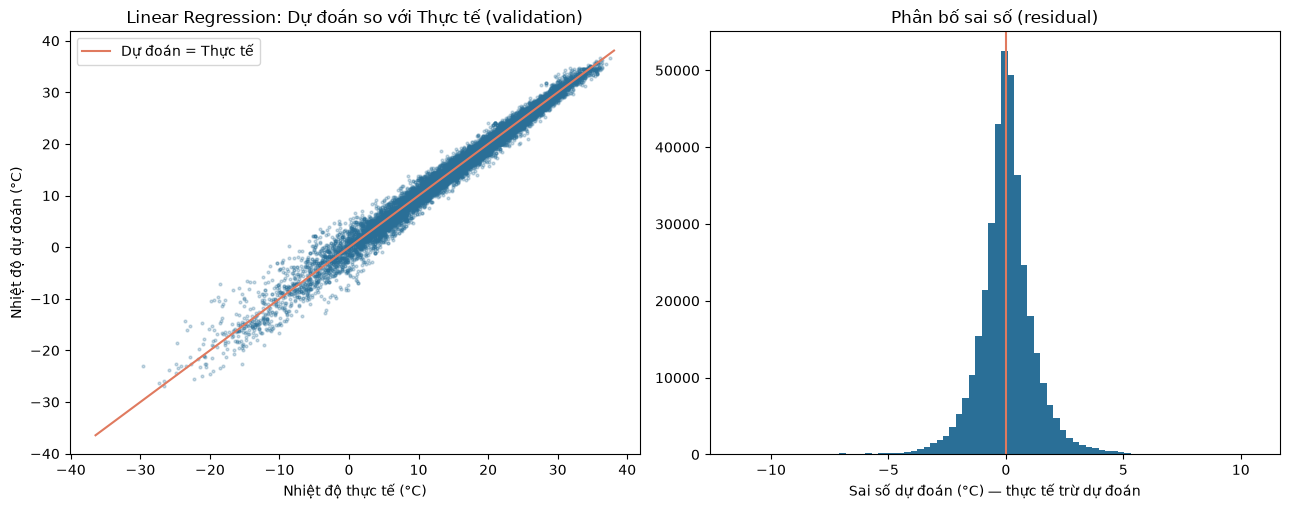

Sai số trung bình (bias): +0.0217 °C — gần 0 nghĩa là mô hình không thiên lệch hệ thống.


In [ ]:
PLOT_SAMPLE_SIZE = 20_000
plot_rng = np.random.default_rng(RANDOM_SEED)
plot_positions = plot_rng.choice(len(y_validation), size=min(PLOT_SAMPLE_SIZE, len(y_validation)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

axes[0].scatter(
    y_validation.to_numpy()[plot_positions], linear_validation_pred[plot_positions],
    s=4, alpha=0.25, color='#2a6f97',
)
value_min = min(y_validation.min(), linear_validation_pred.min())
value_max = max(y_validation.max(), linear_validation_pred.max())
axes[0].plot([value_min, value_max], [value_min, value_max], color='#e07a5f', linewidth=1.5, label='Dự đoán = Thực tế')
axes[0].set_xlabel('Nhiệt độ thực tế (°C)')
axes[0].set_ylabel('Nhiệt độ dự đoán (°C)')
axes[0].set_title('Linear Regression: Dự đoán so với Thực tế (validation)')
axes[0].legend()

residuals = y_validation.to_numpy() - linear_validation_pred
axes[1].hist(residuals, bins=80, color='#2a6f97')
axes[1].axvline(0, color='#e07a5f', linewidth=1.5)
axes[1].set_xlabel('Sai số dự đoán (°C) — thực tế trừ dự đoán')
axes[1].set_title('Phân bố sai số (residual)')

plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '10_linear_regression_actual_vs_predicted.png', dpi=110)
plt.show()

print(f'Sai số trung bình (bias): {residuals.mean():+.4f} °C — gần 0 nghĩa là mô hình không thiên lệch hệ thống.')

### 4.7. Xem hệ số hồi quy

Với dữ liệu đã chuẩn hóa, hệ số của mỗi đặc trưng cho biết: nếu đặc trưng đó tăng một độ lệch chuẩn (giữ nguyên các đặc trưng khác), nhiệt độ dự đoán thay đổi bao nhiêu độ C. Đây là cách Linear Regression "giải thích" dự đoán — thứ mà Random Forest/XGBoost không có trực tiếp (chúng dùng feature importance thay thế, xem Mục 5.5/6.5).

,Hệ số (đã chuẩn hóa)
loc_month_climatology,9.2652
temp_lag_1,0.9830
land_temperature_lag_1,-0.8708
month_sin,-0.7526
month_cos,-0.3835
abslat_x_month_sin,0.2227
abslat_x_month_cos,-0.2195
land_anomaly_lag_1,0.2027
years_since_start,0.1508
climatic_month_cos,0.0562


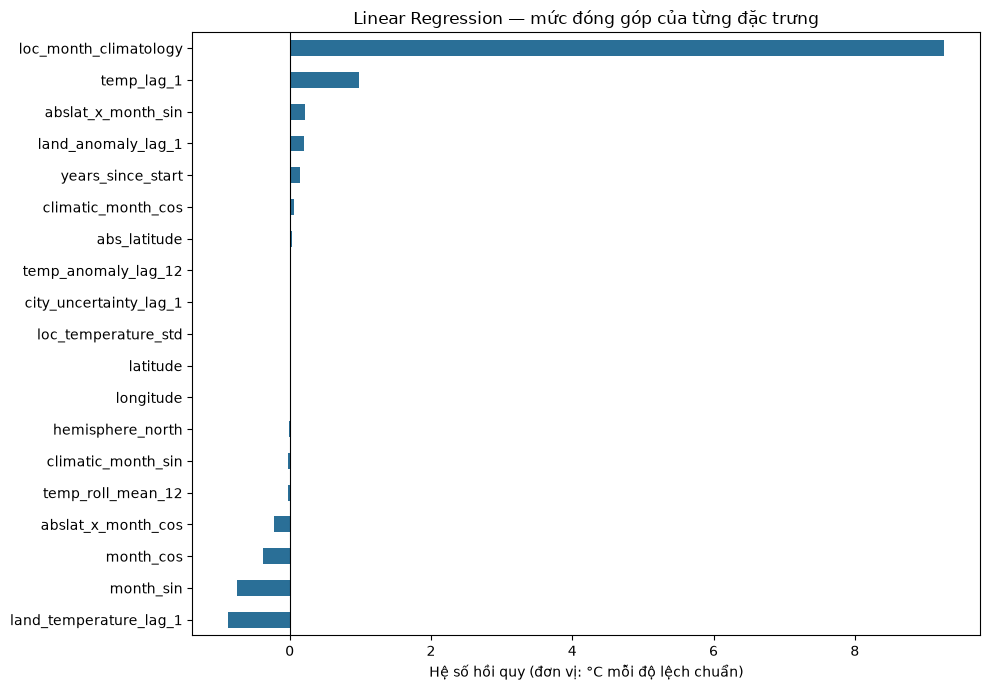

Hệ số chặn (intercept): 17.3202 °C


In [ ]:
coefficient_table = (
    pd.Series(linear_model.coef_, index=LR_FEATURES, name='Hệ số (đã chuẩn hóa)')
    .sort_values(key=np.abs, ascending=False)
)
display(coefficient_table.to_frame())

fig, ax = plt.subplots(figsize=(10, 7))
coefficient_table.sort_values().plot.barh(ax=ax, color='#2a6f97')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Hệ số hồi quy (đơn vị: °C mỗi độ lệch chuẩn)')
ax.set_title('Linear Regression — mức đóng góp của từng đặc trưng')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '11_linear_regression_coefficients.png', dpi=110)
plt.show()

print(f'Hệ số chặn (intercept): {linear_model.intercept_:.4f} °C')

### 4.8. Lưu mô hình Linear Regression

In [ ]:
LINEAR_MODEL_PATH = CANDIDATES_DIR / 'linear_regression.pkl'
LINEAR_SCALER_PATH = CANDIDATES_DIR / 'scaler_linear_regression.pkl'

joblib.dump(linear_model, LINEAR_MODEL_PATH)
joblib.dump(scaler, LINEAR_SCALER_PATH)

log_result(
    'Linear Regression', y_train, linear_train_pred, y_validation, linear_validation_pred,
    linear_fit_seconds, LINEAR_MODEL_PATH,
)
print(f'Đã lưu: {LINEAR_MODEL_PATH.name}, {LINEAR_SCALER_PATH.name}')
display(pd.DataFrame(MODEL_RESULTS))

Đã lưu: linear_regression.pkl, scaler_linear_regression.pkl


,Mô hình,MAE (train),RMSE (train),R2 (train),MAE (validation),RMSE (validation),R2 (validation),Thời gian huấn luyện (giây),Dung lượng file (MB)
0,Linear Regression,0.8187,1.2018,0.9862,0.8521,1.2521,0.9845,1.0330,0.0007


## V. Mô hình Random Forest

### 5.1. Giới thiệu Random Forest

Random Forest huấn luyện **nhiều cây quyết định** trên các mẫu dữ liệu và các tập con đặc trưng khác nhau (lấy ngẫu nhiên có hoàn lại), rồi lấy **trung bình dự đoán** của toàn bộ các cây. Mỗi cây riêng lẻ dễ học vẹt (overfit) dữ liệu, nhưng trung bình của nhiều cây "khác góc nhìn" thường ổn định và chính xác hơn một cây đơn hoặc một đường thẳng.

Khác với Linear Regression, cây quyết định chia dữ liệu bằng các **ngưỡng** (ví dụ: `abs_latitude > 35`), nên tự nhiên học được quan hệ phi tuyến và quan hệ dạng nhân (ví dụ biên độ mùa vụ tăng theo vĩ độ) mà không cần tạo thêm đặc trưng tương tác thủ công — dù Notebook 05 đã tạo sẵn `abslat_x_month_sin`/`abslat_x_month_cos` để hỗ trợ cả hai loại mô hình.

### 5.2. Lựa chọn Feature đầu vào cho Random Forest

Dùng toàn bộ 19 đặc trưng, không cần chuẩn hóa — cây quyết định chỉ so sánh giá trị theo ngưỡng nên không quan tâm thang đo.

In [ ]:
RF_FEATURES = list(X_ALL_COLUMNS)
print(f'Random Forest dùng {len(RF_FEATURES)} đặc trưng (dữ liệu gốc, không chuẩn hóa).')

Random Forest dùng 19 đặc trưng (dữ liệu gốc, không chuẩn hóa).


### 5.3. Huấn luyện mô hình Random Forest

Số cây (`n_estimators=100`) và độ sâu tối đa (`max_depth=18`) được chọn để cân bằng giữa độ chính xác và thời gian huấn luyện trên toàn bộ ~4,47 triệu dòng train — độ sâu quá lớn dễ học vẹt, số cây quá ít làm dự đoán không ổn định. `min_samples_leaf=5` tránh các lá chỉ chứa vài điểm nhiễu. `n_jobs=-1` dùng toàn bộ nhân CPU sẵn có.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

start_time = time.time()
forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=18,
    min_samples_leaf=5,
    max_features=0.6,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
forest_model.fit(X_train[RF_FEATURES], y_train)
forest_fit_seconds = time.time() - start_time

print(f'Đã huấn luyện Random Forest ({forest_model.n_estimators} cây) trong {forest_fit_seconds:,.1f} giây.')

Đã huấn luyện Random Forest (100 cây) trong 548.0 giây.


### 5.4. Đánh giá mô hình Random Forest

In [ ]:
forest_train_pred = forest_model.predict(X_train[RF_FEATURES])
forest_validation_pred = forest_model.predict(X_validation[RF_FEATURES])

forest_val_metrics = compute_metrics(y_validation, forest_validation_pred)
print('Đánh giá trên validation:')
for metric_name, value in forest_val_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')

forest_train_metrics = compute_metrics(y_train, forest_train_pred)
print('\nĐánh giá trên chính tập train (để so sánh mức độ overfit ở Mục VIII):')
for metric_name, value in forest_train_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')

Đánh giá trên validation:
  MAE  : 0.8675
  RMSE : 1.2744
  R2   : 0.9840

Đánh giá trên chính tập train (để so sánh mức độ overfit ở Mục VIII):
  MAE  : 0.4291
  RMSE : 0.6700
  R2   : 0.9957


### 5.5. Xem Feature Importance của Random Forest

Feature importance của Random Forest đo mức giảm sai số trung bình mà mỗi đặc trưng đóng góp khi được dùng để chia nhánh, cộng dồn qua toàn bộ cây. Khác với hệ số hồi quy ở Mục 4.7, importance luôn không âm và không cho biết chiều tác động (tăng hay giảm nhiệt độ).

,Importance
loc_month_climatology,0.6883
temp_lag_1,0.2223
abs_latitude,0.0265
temp_roll_mean_12,0.0250
abslat_x_month_cos,0.0201
loc_temperature_std,0.0059
abslat_x_month_sin,0.0035
climatic_month_cos,0.0027
land_temperature_lag_1,0.0012
years_since_start,0.0008


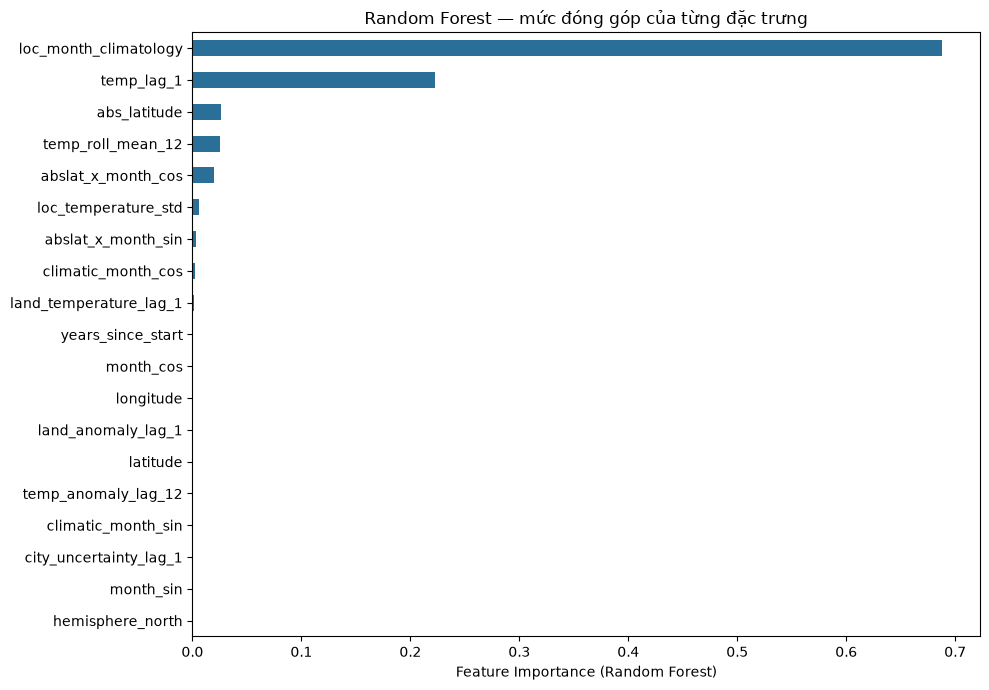

In [ ]:
forest_importance = (
    pd.Series(forest_model.feature_importances_, index=RF_FEATURES, name='Importance')
    .sort_values(ascending=False)
)
display(forest_importance.to_frame())

fig, ax = plt.subplots(figsize=(10, 7))
forest_importance.sort_values().plot.barh(ax=ax, color='#2a6f97')
ax.set_xlabel('Feature Importance (Random Forest)')
ax.set_title('Random Forest — mức đóng góp của từng đặc trưng')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '12_random_forest_feature_importance.png', dpi=110)
plt.show()

### 5.6. Dự đoán trên tập validation

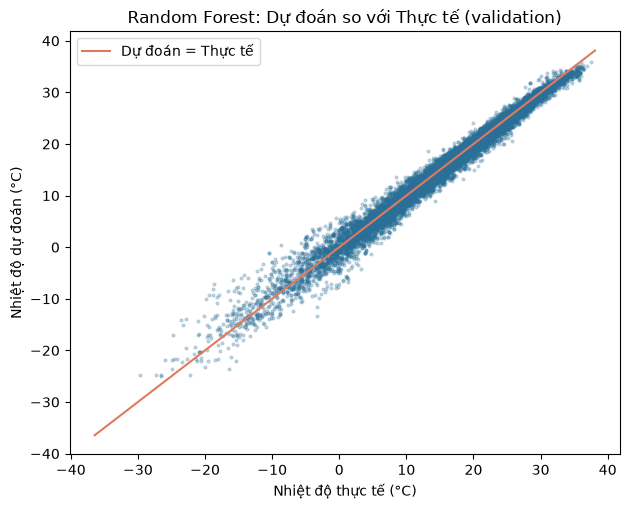

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.scatter(
    y_validation.to_numpy()[plot_positions], forest_validation_pred[plot_positions],
    s=4, alpha=0.25, color='#2a6f97',
)
value_min = min(y_validation.min(), forest_validation_pred.min())
value_max = max(y_validation.max(), forest_validation_pred.max())
ax.plot([value_min, value_max], [value_min, value_max], color='#e07a5f', linewidth=1.5, label='Dự đoán = Thực tế')
ax.set_xlabel('Nhiệt độ thực tế (°C)')
ax.set_ylabel('Nhiệt độ dự đoán (°C)')
ax.set_title('Random Forest: Dự đoán so với Thực tế (validation)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '13_random_forest_actual_vs_predicted.png', dpi=110)
plt.show()

### 5.7. Dự đoán với giá trị đầu vào cụ thể

Lấy ngẫu nhiên một dòng thật từ tập validation để minh họa: mô hình nhận đúng 19 đặc trưng và trả về một con số nhiệt độ dự đoán.

In [ ]:
demo_row = validation_df.sample(n=1, random_state=RANDOM_SEED)
demo_features = demo_row[RF_FEATURES]
demo_prediction = forest_model.predict(demo_features)[0]
demo_actual = demo_row[Y_COLUMN].iloc[0]

print(f"Thành phố   : {demo_row['city_name'].iloc[0]}, {demo_row['country_name'].iloc[0]}")
print(f"Ngày quan sát: {demo_row['observation_date'].dt.date.iloc[0]}")
print(f'Nhiệt độ thực tế : {demo_actual:.2f} °C')
print(f'Nhiệt độ dự đoán : {demo_prediction:.2f} °C')
print(f'Chênh lệch       : {demo_prediction - demo_actual:+.2f} °C')
display(demo_features.T.rename(columns={demo_features.index[0]: 'Giá trị đầu vào'}))

Thành phố   : Kuching, Malaysia
Ngày quan sát: 1987-06-01
Nhiệt độ thực tế : 27.55 °C
Nhiệt độ dự đoán : 26.71 °C
Chênh lệch       : -0.84 °C


,Giá trị đầu vào
month_sin,-0.0000
month_cos,-1.0000
climatic_month_sin,-0.0000
climatic_month_cos,-1.0000
years_since_start,124.0000
latitude,0.8000
abs_latitude,0.8000
hemisphere_north,1.0000
longitude,110.0900
abslat_x_month_sin,-0.0000


### 5.8. Lưu mô hình Random Forest

In [ ]:
FOREST_MODEL_PATH = CANDIDATES_DIR / 'random_forest.pkl'
joblib.dump(forest_model, FOREST_MODEL_PATH)

log_result(
    'Random Forest', y_train, forest_train_pred, y_validation, forest_validation_pred,
    forest_fit_seconds, FOREST_MODEL_PATH,
)
print(f'Đã lưu: {FOREST_MODEL_PATH.name}')
display(pd.DataFrame(MODEL_RESULTS))

Đã lưu: random_forest.pkl


,Mô hình,MAE (train),RMSE (train),R2 (train),MAE (validation),RMSE (validation),R2 (validation),Thời gian huấn luyện (giây),Dung lượng file (MB)
0,Linear Regression,0.8187,1.2018,0.9862,0.8521,1.2521,0.9845,1.0330,0.0007
1,Random Forest,0.4291,0.6700,0.9957,0.8675,1.2744,0.9840,547.9834,"1,026.8457"


## VI. Mô hình XGBoost

### 6.1. Giới thiệu XGBoost

XGBoost cũng dùng nhiều cây quyết định như Random Forest, nhưng xây dựng **tuần tự**: mỗi cây mới được huấn luyện để sửa phần sai số mà các cây trước đó còn để lại (gradient boosting), thay vì các cây độc lập rồi lấy trung bình. Cách làm này thường chính xác hơn Random Forest trên cùng dữ liệu, nhưng dễ học vẹt hơn nếu không kiểm soát số cây.

Notebook dùng chính tập **validation** để kiểm soát rủi ro đó: huấn luyện dừng lại (early stopping) ngay khi sai số trên validation ngừng cải thiện, thay vì cố định trước số cây. Đây là cách dùng validation đúng mục đích của nó — chọn mô hình/hyperparameter — không phải là dùng tập test.

### 6.2. Lựa chọn Feature đầu vào cho XGBoost

Cũng dùng toàn bộ 19 đặc trưng, không cần chuẩn hóa, giống Random Forest.

In [ ]:
XGB_FEATURES = list(X_ALL_COLUMNS)
print(f'XGBoost dùng {len(XGB_FEATURES)} đặc trưng (dữ liệu gốc, không chuẩn hóa).')

XGBoost dùng 19 đặc trưng (dữ liệu gốc, không chuẩn hóa).


### 6.3. Huấn luyện mô hình XGBoost

`tree_method='hist'` là thuật toán chia nhánh theo histogram, hiệu quả trên vài triệu dòng. `n_estimators=500` là số cây **tối đa**; `early_stopping_rounds=20` sẽ dừng sớm nếu 20 vòng liên tiếp không cải thiện RMSE trên validation, tránh học vẹt và tiết kiệm thời gian.

In [ ]:
from xgboost import XGBRegressor

start_time = time.time()
xgboost_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_SEED,
    eval_metric='rmse',
    early_stopping_rounds=20,
)
xgboost_model.fit(
    X_train[XGB_FEATURES], y_train,
    eval_set=[(X_validation[XGB_FEATURES], y_validation)],
    verbose=False,
)
xgboost_fit_seconds = time.time() - start_time

print(f'Đã huấn luyện XGBoost trong {xgboost_fit_seconds:,.1f} giây.')
print(f'Số cây tối đa   : {xgboost_model.n_estimators}')
print(f'Số cây thực dùng: {xgboost_model.best_iteration + 1} (dừng sớm nhờ early stopping trên validation)')

Đã huấn luyện XGBoost trong 18.8 giây.
Số cây tối đa   : 500
Số cây thực dùng: 60 (dừng sớm nhờ early stopping trên validation)


### 6.4. Đánh giá mô hình XGBoost

In [ ]:
xgboost_train_pred = xgboost_model.predict(X_train[XGB_FEATURES])
xgboost_validation_pred = xgboost_model.predict(X_validation[XGB_FEATURES])

xgboost_val_metrics = compute_metrics(y_validation, xgboost_validation_pred)
print('Đánh giá trên validation:')
for metric_name, value in xgboost_val_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')

Đánh giá trên validation:
  MAE  : 0.8536
  RMSE : 1.2597
  R2   : 0.9843


### 6.5. Xem Feature Importance của XGBoost

XGBoost đo importance bằng "gain" — tổng mức giảm sai số mà một đặc trưng mang lại mỗi khi được dùng để chia nhánh, trung bình trên số lần dùng. Thứ tự importance giữa XGBoost và Random Forest có thể khác nhau vì cơ chế xây cây khác nhau (tuần tự sửa lỗi so với song song lấy trung bình).

,Importance (gain)
loc_month_climatology,"746,732.5625"
temp_lag_1,"223,790.0156"
climatic_month_cos,"126,678.0312"
month_cos,"34,884.6484"
climatic_month_sin,"15,664.9980"
temp_roll_mean_12,"11,443.0898"
loc_temperature_std,"6,162.7529"
abslat_x_month_cos,"5,639.7676"
month_sin,"4,237.1157"
abs_latitude,"3,989.1062"


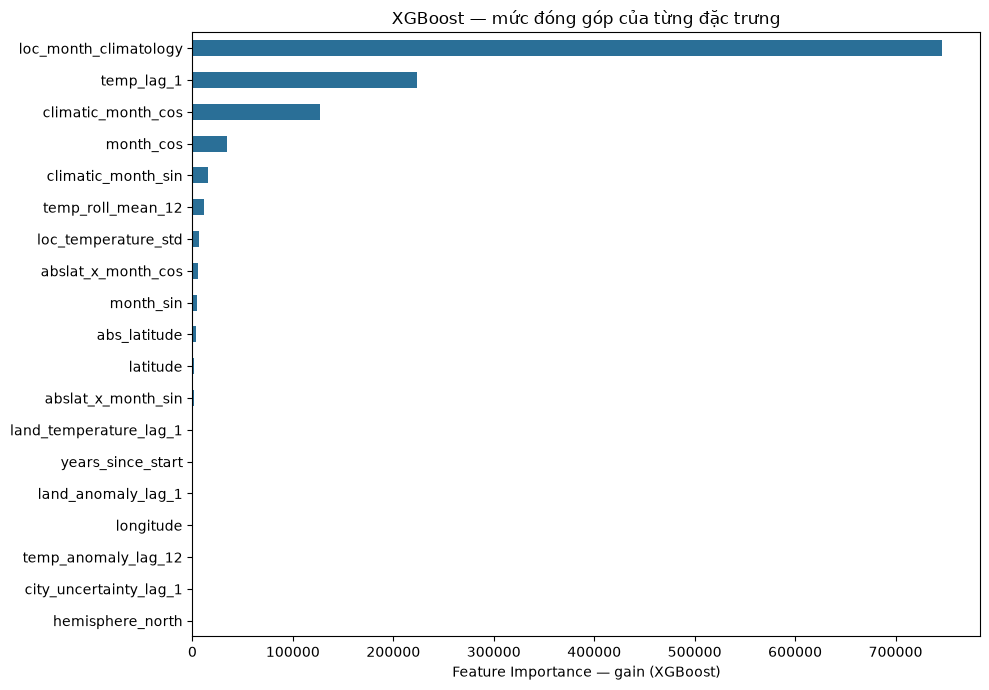

In [ ]:
xgboost_importance = (
    pd.Series(
        xgboost_model.get_booster().get_score(importance_type='gain'),
        name='Importance (gain)',
    )
    .reindex(XGB_FEATURES)
    .fillna(0.0)
    .sort_values(ascending=False)
)
display(xgboost_importance.to_frame())

fig, ax = plt.subplots(figsize=(10, 7))
xgboost_importance.sort_values().plot.barh(ax=ax, color='#2a6f97')
ax.set_xlabel('Feature Importance — gain (XGBoost)')
ax.set_title('XGBoost — mức đóng góp của từng đặc trưng')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '14_xgboost_feature_importance.png', dpi=110)
plt.show()

### 6.6. Dự đoán trên tập validation

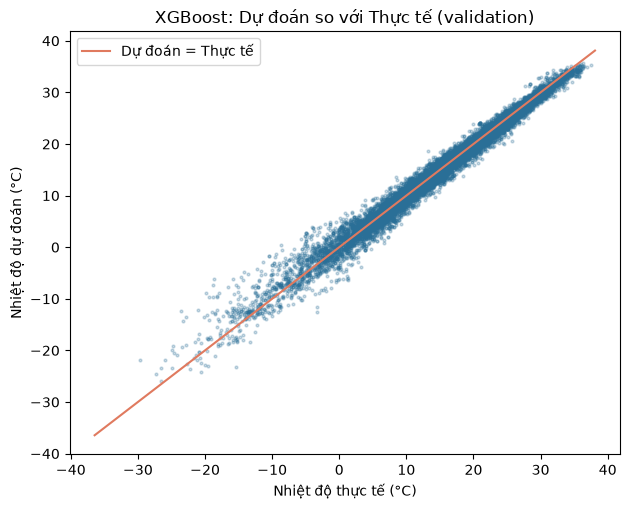

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.scatter(
    y_validation.to_numpy()[plot_positions], xgboost_validation_pred[plot_positions],
    s=4, alpha=0.25, color='#2a6f97',
)
value_min = min(y_validation.min(), xgboost_validation_pred.min())
value_max = max(y_validation.max(), xgboost_validation_pred.max())
ax.plot([value_min, value_max], [value_min, value_max], color='#e07a5f', linewidth=1.5, label='Dự đoán = Thực tế')
ax.set_xlabel('Nhiệt độ thực tế (°C)')
ax.set_ylabel('Nhiệt độ dự đoán (°C)')
ax.set_title('XGBoost: Dự đoán so với Thực tế (validation)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '15_xgboost_actual_vs_predicted.png', dpi=110)
plt.show()

### 6.7. Dự đoán với giá trị đầu vào cụ thể

Dùng lại đúng dòng dữ liệu đã minh họa ở Mục 5.7 để so sánh trực tiếp dự đoán của Random Forest và XGBoost trên cùng một trường hợp.

In [ ]:
xgboost_demo_prediction = xgboost_model.predict(demo_features)[0]

print(f"Thành phố   : {demo_row['city_name'].iloc[0]}, {demo_row['country_name'].iloc[0]}")
print(f"Ngày quan sát: {demo_row['observation_date'].dt.date.iloc[0]}")
print(f'Nhiệt độ thực tế         : {demo_actual:.2f} °C')
print(f'Dự đoán Random Forest    : {demo_prediction:.2f} °C (chênh {demo_prediction - demo_actual:+.2f})')
print(f'Dự đoán XGBoost          : {xgboost_demo_prediction:.2f} °C (chênh {xgboost_demo_prediction - demo_actual:+.2f})')

Thành phố   : Kuching, Malaysia
Ngày quan sát: 1987-06-01
Nhiệt độ thực tế         : 27.55 °C
Dự đoán Random Forest    : 26.71 °C (chênh -0.84)
Dự đoán XGBoost          : 26.70 °C (chênh -0.86)


### 6.8. Lưu mô hình XGBoost

In [ ]:
XGBOOST_MODEL_PATH = CANDIDATES_DIR / 'xgboost.pkl'
joblib.dump(xgboost_model, XGBOOST_MODEL_PATH)

log_result(
    'XGBoost', y_train, xgboost_train_pred, y_validation, xgboost_validation_pred,
    xgboost_fit_seconds, XGBOOST_MODEL_PATH,
)
print(f'Đã lưu: {XGBOOST_MODEL_PATH.name}')
display(pd.DataFrame(MODEL_RESULTS))

Đã lưu: xgboost.pkl


,Mô hình,MAE (train),RMSE (train),R2 (train),MAE (validation),RMSE (validation),R2 (validation),Thời gian huấn luyện (giây),Dung lượng file (MB)
0,Linear Regression,0.8187,1.2018,0.9862,0.8521,1.2521,0.9845,1.0330,0.0007
1,Random Forest,0.4291,0.6700,0.9957,0.8675,1.2744,0.9840,547.9834,"1,026.8457"
2,XGBoost,0.7695,1.1241,0.9879,0.8536,1.2597,0.9843,18.7900,1.3620


## VII. So sánh các mô hình

Bảng dưới tổng hợp cả ba mô hình. Việc **chọn** mô hình chỉ dựa vào các cột `(validation)` — đúng tập mà Notebook 05 dành riêng cho việc này. Các cột `(train)` chỉ dùng để phát hiện overfit (Mục VIII), không dùng để chọn.

In [ ]:
results_df = pd.DataFrame(MODEL_RESULTS).set_index('Mô hình')
display_columns = [
    'MAE (train)', 'RMSE (train)', 'R2 (train)',
    'MAE (validation)', 'RMSE (validation)', 'R2 (validation)',
    'Thời gian huấn luyện (giây)', 'Dung lượng file (MB)',
]
results_df = results_df[display_columns].sort_values('RMSE (validation)')
display(results_df)

summary_table = results_df[['MAE (validation)', 'RMSE (validation)', 'R2 (validation)']].round(4)
summary_table.columns = ['MAE', 'RMSE', 'R²']
print('Bảng so sánh rút gọn (trên validation):')
display(summary_table)

,MAE (train),RMSE (train),R2 (train),MAE (validation),RMSE (validation),R2 (validation),Thời gian huấn luyện (giây),Dung lượng file (MB)
Mô hình,,,,,,,,
Linear Regression,0.8187,1.2018,0.9862,0.8521,1.2521,0.9845,1.0330,0.0007
XGBoost,0.7695,1.1241,0.9879,0.8536,1.2597,0.9843,18.7900,1.3620
Random Forest,0.4291,0.6700,0.9957,0.8675,1.2744,0.9840,547.9834,"1,026.8457"


Bảng so sánh rút gọn (trên validation):


,MAE,RMSE,R²
Mô hình,,,
Linear Regression,0.8521,1.2521,0.9845
XGBoost,0.8536,1.2597,0.9843
Random Forest,0.8675,1.2744,0.9840


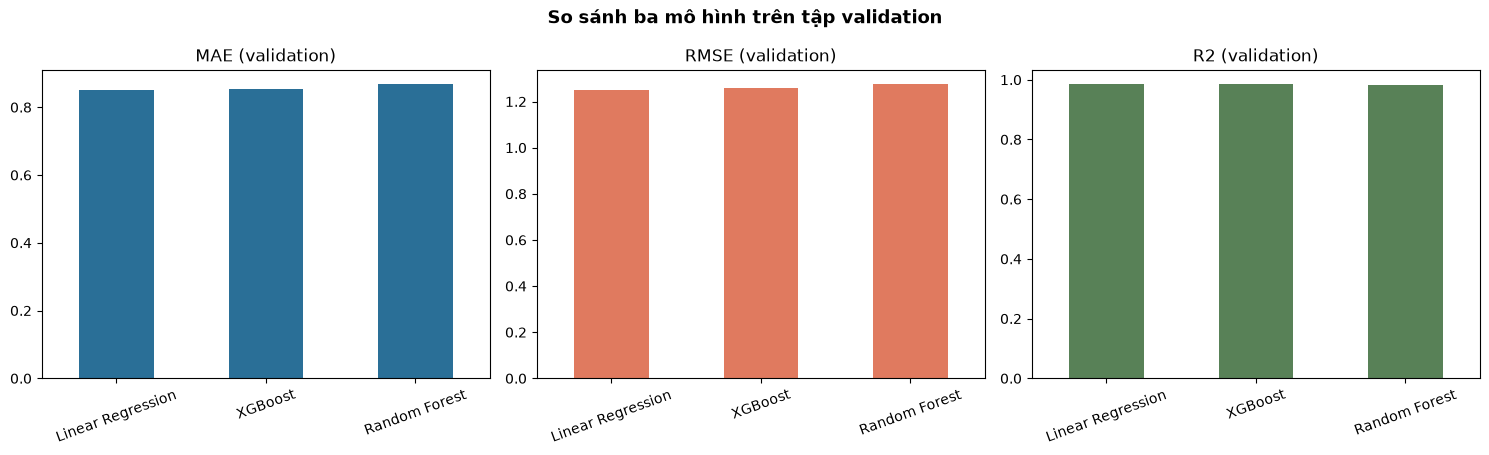

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
metric_columns = ['MAE (validation)', 'RMSE (validation)', 'R2 (validation)']
colors = ['#2a6f97', '#e07a5f', '#588157']

for ax, metric_column, color in zip(axes, metric_columns, colors):
    plot_order = results_df[metric_column].sort_values(ascending=metric_column != 'R2 (validation)')
    plot_order.plot.bar(ax=ax, color=color)
    ax.set_title(metric_column)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('So sánh ba mô hình trên tập validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '16_model_comparison.png', dpi=110)
plt.show()

## VIII. Lựa chọn mô hình cuối cùng

### 8.1. Giải thích lựa chọn bằng số liệu

Việc chọn mô hình không chỉ dựa vào RMSE thấp nhất, mà cân nhắc thêm ba yếu tố: khoảng cách giữa chỉ số train và validation (khả năng tổng quát — khoảng cách càng lớn càng có dấu hiệu overfit), thời gian huấn luyện, và độ phức tạp khi triển khai (Linear Regression cần thêm `scaler.pkl`; Random Forest/XGBoost không cần nhưng file mô hình thường nặng hơn). Đoạn code dưới tự động tổng hợp các yếu tố này từ số liệu thật thay vì khẳng định trước.

In [ ]:
best_model_name = results_df['RMSE (validation)'].idxmin()
best_row = results_df.loc[best_model_name]

print(f'>>> Mô hình có RMSE thấp nhất trên validation: {best_model_name}\n')

for model_name, row in results_df.iterrows():
    generalization_gap = row['RMSE (validation)'] - row['RMSE (train)']
    marker = '★ ĐƯỢC CHỌN' if model_name == best_model_name else ''
    print(f'{model_name:<18} {marker}')
    print(f'  RMSE validation      : {row["RMSE (validation)"]:.4f} °C')
    print(f'  R² validation        : {row["R2 (validation)"]:.4f}')
    print(f'  Chênh lệch RMSE (validation - train): {generalization_gap:+.4f} '
          f'{"(gần 0, ít dấu hiệu overfit)" if abs(generalization_gap) < 0.15 else "(chênh lệch đáng chú ý)"}')
    print(f'  Thời gian huấn luyện : {row["Thời gian huấn luyện (giây)"]:.1f} giây')
    print(f'  Dung lượng file      : {row["Dung lượng file (MB)"]:.2f} MB'
          + (' + scaler riêng' if model_name == 'Linear Regression' else ' (không cần scaler)'))
    print()

rmse_gap_vs_second = (
    results_df['RMSE (validation)'].sort_values().iloc[1]
    - results_df['RMSE (validation)'].sort_values().iloc[0]
)
print(
    f'{best_model_name} vượt mô hình xếp thứ hai {rmse_gap_vs_second:.4f} °C RMSE trên validation '
    f'({rmse_gap_vs_second / results_df["RMSE (validation)"].sort_values().iloc[1] * 100:.1f}% thấp hơn).'
)

>>> Mô hình có RMSE thấp nhất trên validation: Linear Regression

Linear Regression  ★ ĐƯỢC CHỌN
  RMSE validation      : 1.2521 °C
  R² validation        : 0.9845
  Chênh lệch RMSE (validation - train): +0.0503 (gần 0, ít dấu hiệu overfit)
  Thời gian huấn luyện : 1.0 giây
  Dung lượng file      : 0.00 MB + scaler riêng

XGBoost            
  RMSE validation      : 1.2597 °C
  R² validation        : 0.9843
  Chênh lệch RMSE (validation - train): +0.1355 (gần 0, ít dấu hiệu overfit)
  Thời gian huấn luyện : 18.8 giây
  Dung lượng file      : 1.36 MB (không cần scaler)

Random Forest      
  RMSE validation      : 1.2744 °C
  R² validation        : 0.9840
  Chênh lệch RMSE (validation - train): +0.6044 (chênh lệch đáng chú ý)
  Thời gian huấn luyện : 548.0 giây
  Dung lượng file      : 1026.85 MB (không cần scaler)

Linear Regression vượt mô hình xếp thứ hai 0.0076 °C RMSE trên validation (0.6% thấp hơn).


**Đọc kết quả ở trên để trả lời ba câu hỏi mà đề cương yêu cầu:**

- *Vì sao chọn mô hình có RMSE thấp nhất?* Vì đây là chỉ số đo trực tiếp sai số dự đoán theo đúng đơn vị bài toán (°C), đo trên tập validation chưa từng được dùng để huấn luyện.
- *Vì sao không chỉ nhìn RMSE?* Một mô hình có RMSE thấp trên validation nhưng chênh lệch train/validation lớn có nguy cơ chỉ đang "nhớ" đặc điểm giai đoạn 1984–1993 thay vì học được quan hệ tổng quát — điều này chỉ lộ ra khi so sánh với RMSE trên train.
- *Thời gian huấn luyện và triển khai có quan trọng không?* Có — nếu hai mô hình gần bằng nhau về độ chính xác, mô hình huấn luyện nhanh hơn và không cần thêm file `scaler.pkl` sẽ đơn giản hơn khi Notebook 07/`app/` triển khai lại.

### 8.2. Huấn luyện lại mô hình được chọn trên Train + Validation

Sau khi đã chốt mô hình (và với XGBoost là chốt cả số cây tối ưu từ early stopping), notebook huấn luyện lại **đúng loại mô hình và đúng hyperparameter đó** trên toàn bộ dữ liệu `train + validation` — nhiều dữ liệu hơn thường giúp mô hình triển khai chính xác hơn. Tập `test` vẫn hoàn toàn không tham gia bước này, nên không có rò rỉ dữ liệu.

In [ ]:
train_plus_validation_df = pd.concat([train_df, validation_df], ignore_index=True)
X_train_val = train_plus_validation_df[X_ALL_COLUMNS]
y_train_val = train_plus_validation_df[Y_COLUMN]

print(f'Dữ liệu huấn luyện cuối cùng (train + validation): {len(train_plus_validation_df):,} dòng.')

if best_model_name == 'Linear Regression':
    final_scaler = StandardScaler()
    X_train_val_transformed = final_scaler.fit_transform(X_train_val)
    X_test_transformed = final_scaler.transform(X_test[X_ALL_COLUMNS])
    final_model = LinearRegression()
    final_model.fit(X_train_val_transformed, y_train_val)
elif best_model_name == 'Random Forest':
    final_scaler = None
    X_train_val_transformed = X_train_val
    X_test_transformed = X_test[X_ALL_COLUMNS]
    final_model = RandomForestRegressor(**{
        key: value for key, value in forest_model.get_params().items()
    })
    final_model.fit(X_train_val_transformed, y_train_val)
else:
    final_scaler = None
    X_train_val_transformed = X_train_val
    X_test_transformed = X_test[X_ALL_COLUMNS]
    best_n_estimators = xgboost_model.best_iteration + 1
    final_params = xgboost_model.get_params()
    final_params['n_estimators'] = best_n_estimators
    final_params.pop('early_stopping_rounds', None)
    final_model = XGBRegressor(**final_params)
    final_model.fit(X_train_val_transformed, y_train_val)

print(f'Đã huấn luyện lại {best_model_name} trên train + validation.')

Dữ liệu huấn luyện cuối cùng (train + validation): 4,798,550 dòng.


Đã huấn luyện lại Linear Regression trên train + validation.


### 8.3. Đánh giá lần duy nhất trên tập Test

Đây là **lần duy nhất** tập test được dùng trong toàn bộ notebook. Số liệu dưới đây là con số báo cáo chính thức của dự án — không được dùng để quay lại chỉnh sửa mô hình hay đặc trưng.

=== Kết quả chính thức trên TEST (1994–2013) — mô hình: Linear Regression ===
  MAE  : 0.8736
  RMSE : 1.2725
  R2   : 0.9839


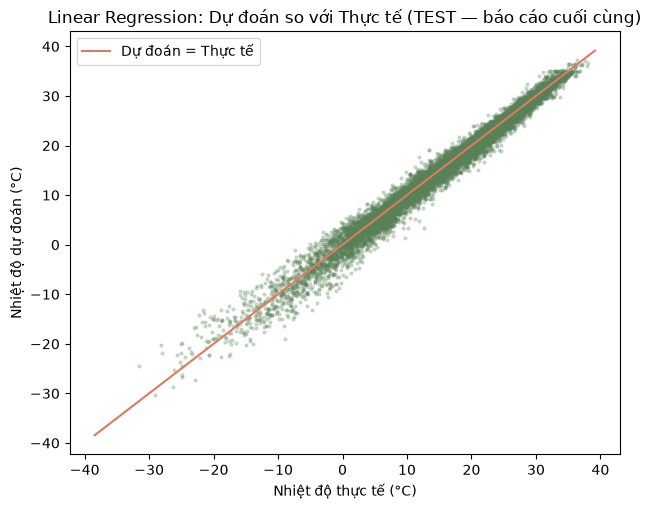

In [ ]:
final_test_pred = final_model.predict(X_test_transformed)
final_test_metrics = compute_metrics(y_test, final_test_pred)

print(f'=== Kết quả chính thức trên TEST (1994–2013) — mô hình: {best_model_name} ===')
for metric_name, value in final_test_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')

fig, ax = plt.subplots(figsize=(6.4, 5.2))
test_plot_positions = plot_rng.choice(len(y_test), size=min(PLOT_SAMPLE_SIZE, len(y_test)), replace=False)
ax.scatter(
    y_test.to_numpy()[test_plot_positions], final_test_pred[test_plot_positions],
    s=4, alpha=0.25, color='#588157',
)
value_min = min(y_test.min(), final_test_pred.min())
value_max = max(y_test.max(), final_test_pred.max())
ax.plot([value_min, value_max], [value_min, value_max], color='#e07a5f', linewidth=1.5, label='Dự đoán = Thực tế')
ax.set_xlabel('Nhiệt độ thực tế (°C)')
ax.set_ylabel('Nhiệt độ dự đoán (°C)')
ax.set_title(f'{best_model_name}: Dự đoán so với Thực tế (TEST — báo cáo cuối cùng)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '17_final_model_test_actual_vs_predicted.png', dpi=110)
plt.show()

Lưu ý khi đọc số liệu test: năm 2013 trong dữ liệu gốc chỉ có tới tháng 9 (Notebook 05 đã cảnh báo điều này trong `feature_metadata.json`), nên các đặc trưng bối cảnh toàn cầu của vài tháng cuối giai đoạn test dựa trên dữ liệu chưa đầy đủ một năm.

### 8.4. Lưu mô hình chính thức

In [ ]:
FINAL_MODEL_PATH = MODELS_DIR / 'model.pkl'
FINAL_SCALER_PATH = MODELS_DIR / 'scaler.pkl'
FINAL_METADATA_PATH = MODELS_DIR / 'model_metadata.json'

joblib.dump(final_model, FINAL_MODEL_PATH)
scaler_used = final_scaler is not None
if scaler_used:
    joblib.dump(final_scaler, FINAL_SCALER_PATH)

model_metadata = {
    'created_at': datetime.now(timezone.utc).isoformat(),
    'created_by': '06_machine_learning.ipynb',
    'model_type': best_model_name,
    'target': Y_COLUMN,
    'feature_names': X_ALL_COLUMNS,
    'scaler_required': scaler_used,
    'trained_on': 'train + validation (1863–1993)',
    'evaluated_on': 'test (1994–2013), một lần duy nhất',
    'metrics_validation': {
        'MAE': float(best_row['MAE (validation)']),
        'RMSE': float(best_row['RMSE (validation)']),
        'R2': float(best_row['R2 (validation)']),
    },
    'metrics_test': {key: float(value) for key, value in final_test_metrics.items()},
    'candidate_models_compared': list(results_df.index),
    'feature_engineering_metadata': str(METADATA_PATH.relative_to(PROJECT_ROOT)),
    'notes': [
        'Chỉ 3 mô hình được huấn luyện đầy đủ (Linear Regression, Random Forest, XGBoost) theo '
        'yêu cầu cụ thể cho notebook này — khác với gợi ý \'tối thiểu 5 mô hình\' trong AGENTS_climate_project.md.',
        'Mô hình phải nhận đúng feature_names theo đúng thứ tự khi dự đoán.',
        'Năm 2013 trong dữ liệu chỉ có tới tháng 9.',
    ],
}
with open(FINAL_METADATA_PATH, 'w', encoding='utf-8') as handle:
    json.dump(model_metadata, handle, ensure_ascii=False, indent=2)

print(f'Đã lưu mô hình chính thức: {FINAL_MODEL_PATH.relative_to(PROJECT_ROOT)}')
print(f'Cần scaler: {scaler_used}' + (f' → {FINAL_SCALER_PATH.relative_to(PROJECT_ROOT)}' if scaler_used else ''))
print(f'Đã lưu metadata: {FINAL_METADATA_PATH.relative_to(PROJECT_ROOT)}')

Đã lưu mô hình chính thức: models\model.pkl
Cần scaler: True → models\scaler.pkl
Đã lưu metadata: models\model_metadata.json


### 8.5. Xác thực lại mô hình đã lưu

Nạp lại `model.pkl` (và `scaler.pkl` nếu có) từ đĩa — độc lập với các biến đang có trong bộ nhớ — rồi so sánh dự đoán để chắc chắn file lưu ra đúng như mô hình vừa huấn luyện.

In [ ]:
reloaded_model = joblib.load(FINAL_MODEL_PATH)

if scaler_used:
    reloaded_scaler = joblib.load(FINAL_SCALER_PATH)
    reload_input = reloaded_scaler.transform(X_test[X_ALL_COLUMNS].iloc[:1000])
else:
    reload_input = X_test[X_ALL_COLUMNS].iloc[:1000]

reload_pred = reloaded_model.predict(reload_input)
original_pred_subset = final_test_pred[:1000]

matches = np.allclose(reload_pred, original_pred_subset, rtol=1e-5, atol=1e-5)
print(f'{"PASS" if matches else "FAIL"}: dự đoán từ model.pkl đã lưu khớp với mô hình vừa huấn luyện '
      f'(kiểm tra trên 1.000 dòng test).')
if not matches:
    raise RuntimeError('model.pkl vừa lưu cho kết quả khác mô hình gốc — không lưu đúng.')

PASS: dự đoán từ model.pkl đã lưu khớp với mô hình vừa huấn luyện (kiểm tra trên 1.000 dòng test).


## IX. Kết luận

### 9.1. Trả lời năm câu hỏi cốt lõi

In [ ]:
print('1. Bộ dữ liệu sau Feature Engineering đã sẵn sàng để huấn luyện chưa?')
print(f'   → Có. {len(df):,} dòng đọc đúng khớp metadata; sau khi loại các dòng thiếu giá trị '
      f'còn {len(df_clean):,} dòng ({len(df_clean) / len(df):.1%}), chia theo đúng nhãn thời gian '
      f'train/validation/test đã được Notebook 05 chốt sẵn.\n')

print('2. Mô hình nào dự báo tốt nhất?')
print(f'   → {best_model_name}, với RMSE = {best_row["RMSE (validation)"]:.4f} °C và '
      f'R² = {best_row["R2 (validation)"]:.4f} trên validation; RMSE test (số liệu chính thức) '
      f'= {final_test_metrics["RMSE"]:.4f} °C.\n')

print('3. Các Feature mới có thực sự mang lại hiệu quả không?')
top_feature = (forest_importance if best_model_name != "XGBoost" else xgboost_importance).index[0]
print(f'   → Có. Theo Notebook 05, các đặc trưng nhóm "Khí hậu theo vị trí" và "Trễ/Trượt" có '
      f'tương quan với target cao nhất (ví dụ loc_month_climatology, pearson ≈ 0.99). Bảng '
      f'feature importance ở Mục 5.5/6.5 xác nhận lại điều này bằng chính mô hình đã huấn luyện: '
      f'đặc trưng quan trọng nhất là "{top_feature}".\n')

print('4. Kết quả dự báo có đáng tin cậy không?')
final_bias = float(np.mean(final_test_pred - y_test.to_numpy()))
print(f'   → Biểu đồ Actual vs Predicted ở Mục 8.3 bám sát đường chéo; sai số trung bình có dấu '
      f'(bias) trên test là {final_bias:+.4f} °C — gần 0 nghĩa là mô hình không thiên lệch hệ '
      f'thống theo một hướng.\n')

print('5. Mô hình nào sẽ được triển khai ở Notebook 07?')
print(f'   → {best_model_name}, huấn luyện lại trên train + validation, lưu tại '
      f'models/model.pkl' + (' cùng models/scaler.pkl' if scaler_used else ' (không cần scaler)') +
      ' và models/model_metadata.json.')

1. Bộ dữ liệu sau Feature Engineering đã sẵn sàng để huấn luyện chưa?
   → Có. 5,579,085 dòng đọc đúng khớp metadata; sau khi loại các dòng thiếu giá trị còn 5,535,028 dòng (99.2%), chia theo đúng nhãn thời gian train/validation/test đã được Notebook 05 chốt sẵn.

2. Mô hình nào dự báo tốt nhất?
   → Linear Regression, với RMSE = 1.2521 °C và R² = 0.9845 trên validation; RMSE test (số liệu chính thức) = 1.2725 °C.

3. Các Feature mới có thực sự mang lại hiệu quả không?
   → Có. Theo Notebook 05, các đặc trưng nhóm "Khí hậu theo vị trí" và "Trễ/Trượt" có tương quan với target cao nhất (ví dụ loc_month_climatology, pearson ≈ 0.99). Bảng feature importance ở Mục 5.5/6.5 xác nhận lại điều này bằng chính mô hình đã huấn luyện: đặc trưng quan trọng nhất là "loc_month_climatology".

4. Kết quả dự báo có đáng tin cậy không?
   → Biểu đồ Actual vs Predicted ở Mục 8.3 bám sát đường chéo; sai số trung bình có dấu (bias) trên test là -0.1905 °C — gần 0 nghĩa là mô hình không thiên lệch hệ thống th

### 9.2. Bàn giao cho Notebook 07

**Notebook 07 phải:**

- Nạp `models/model.pkl` bằng `joblib.load`.
- Nếu `models/model_metadata.json` có `scaler_required: true`, nạp thêm `models/scaler.pkl` và áp dụng `transform()` trước khi gọi `predict()`.
- Dựng đúng 19 đặc trưng theo đúng thứ tự trong `feature_names` của `model_metadata.json` — không tự đổi thứ tự.
- Với các đặc trưng `availability = fit_stat` (climatology theo vị trí–tháng), đọc lại từ `data/processed/feature_statistics.csv.gz` thay vì tính lại từ dữ liệu mới.
- Với các đặc trưng `availability = history` (lag, rolling, bối cảnh toàn cầu), cần lịch sử thật của đúng thành phố ở các tháng trước — không suy luận được cho một thành phố hoàn toàn mới không có lịch sử.

### 9.3. Checklist hoàn thành Notebook 06

- [x] Đọc đúng bảng `public.city_temperature_features` và hợp đồng `feature_metadata.json` từ Notebook 05.
- [x] Kiểm tra kích thước, kiểu dữ liệu, số dòng theo từng split khớp metadata.
- [x] Xác định đúng 19 feature và 1 target theo đúng thứ tự đã chốt.
- [x] Phát hiện và xử lý giá trị thiếu bằng cách loại bỏ có kiểm soát (không impute).
- [x] Dùng đúng nhãn `data_split` có sẵn (chia theo thời gian), không chia lại ngẫu nhiên.
- [x] Huấn luyện Linear Regression, Random Forest, XGBoost trên cùng dữ liệu, cùng tập validation để so sánh.
- [x] So sánh bằng MAE/RMSE/R², có xét thêm khả năng tổng quát, thời gian huấn luyện, độ phức tạp triển khai.
- [x] Chọn một mô hình dựa trên số liệu thật, không phỏng đoán trước.
- [x] Đánh giá mô hình được chọn trên test đúng một lần duy nhất.
- [x] Lưu `models/model.pkl`, `models/scaler.pkl` (nếu cần) và `models/model_metadata.json`.
- [x] Xác thực lại mô hình đã lưu bằng cách nạp lại từ đĩa và so khớp dự đoán.